# 👥 Customer Clustering — End-to-End Pipeline
**Midterm Assignment — Machine Learning Class**

| | |
|---|---|
| **Nama** | `Mohammad Fauzi Hadiwijaya` |
| **NIM** | `101032300044` |
| **Kelas** | `TK-47-04` |

---
## Pipeline Overview
1. Setup & Install Libraries
2. Load Dataset
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing
5. Menentukan Jumlah Cluster Optimal
6. Model Training (K-Means, Hierarchical, DBSCAN)
7. Evaluasi Cluster
8. Visualisasi & Interpretasi Cluster

## 1. Setup & Install Libraries

In [1]:
!pip install yellowbrick --quiet
print('✅ Libraries installed!')

✅ Libraries installed!


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

# Clustering Models
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

# Evaluasi
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Visualisasi
from scipy.cluster.hierarchy import dendrogram, linkage
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

SEED = 42
np.random.seed(SEED)

print('✅ All libraries imported!')

✅ All libraries imported!


## 2. Load Dataset

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# ⚠️ Sesuaikan path jika nama folder berbeda
DATA_PATH = '/content/drive/MyDrive/midterm-m1/clusteringmidterm.csv'

print('📂 Loading dataset...')
df = pd.read_csv(DATA_PATH)

print(f'✅ Dataset shape : {df.shape}')
display(df.head())

📂 Loading dataset...
✅ Dataset shape : (8950, 18)


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


## 3. Exploratory Data Analysis (EDA)

In [5]:
print('=== Info Dataset ===')
print(df.info())
print('\n=== Statistik Deskriptif ===')
display(df.describe())

=== Info Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null 

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [6]:
# Missing values
missing = df.isnull().sum()
missing = missing[missing > 0]
print(f'Kolom dengan missing values:')
print(missing if len(missing) > 0 else 'Tidak ada missing values ✅')

Kolom dengan missing values:
CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64


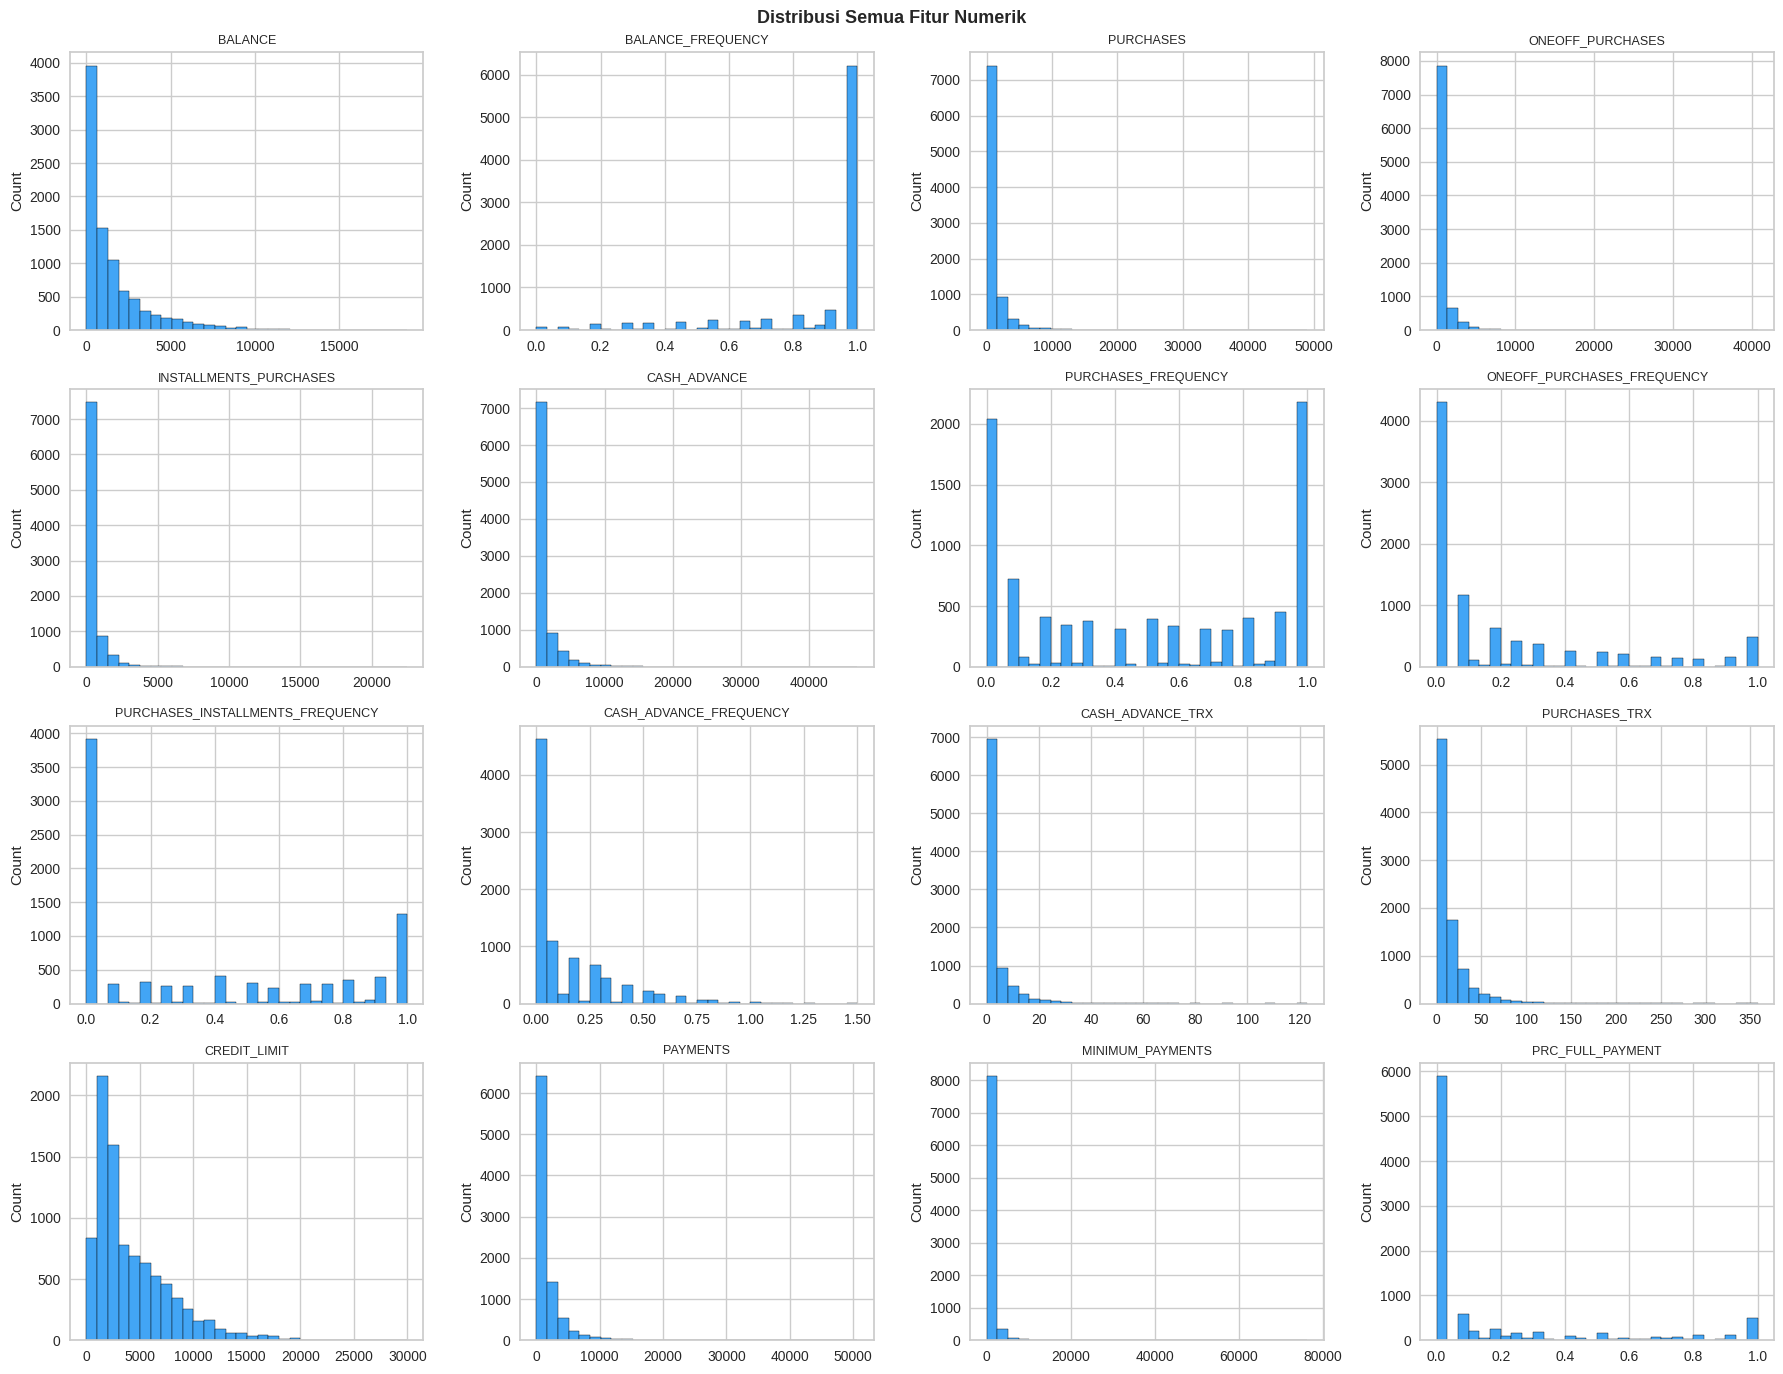

In [7]:
# Distribusi semua fitur numerik
num_cols = df.select_dtypes(include='number').columns.tolist()

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(num_cols[:16]):
    axes[i].hist(df[col].dropna(), bins=30, color='#42A5F5', edgecolor='black')
    axes[i].set_title(col, fontsize=9)
    axes[i].set_ylabel('Count')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Semua Fitur Numerik', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

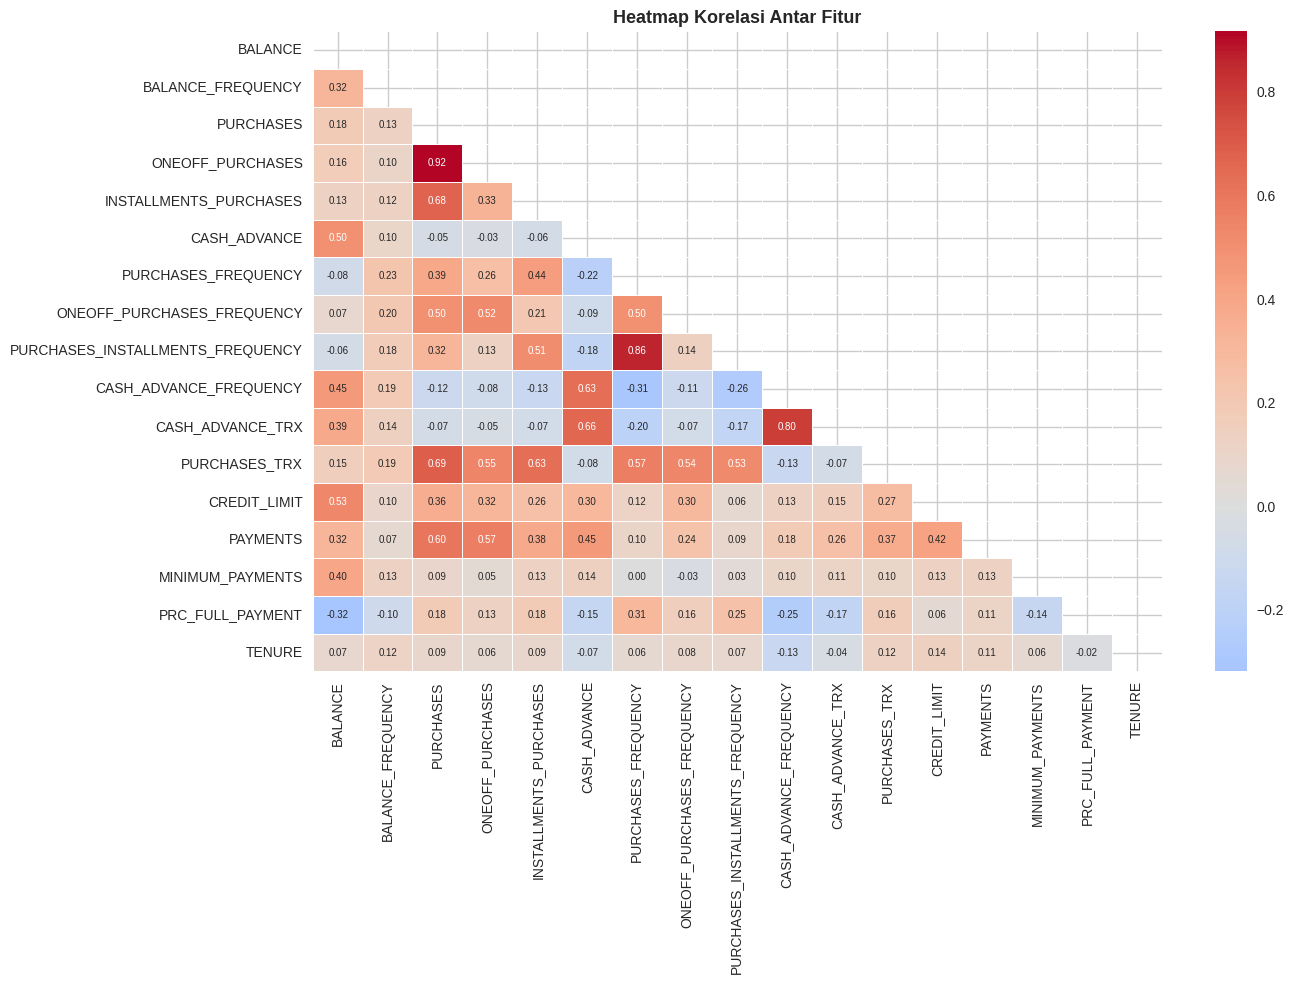

In [8]:
# Heatmap korelasi
plt.figure(figsize=(14, 10))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 7})
plt.title('Heatmap Korelasi Antar Fitur', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

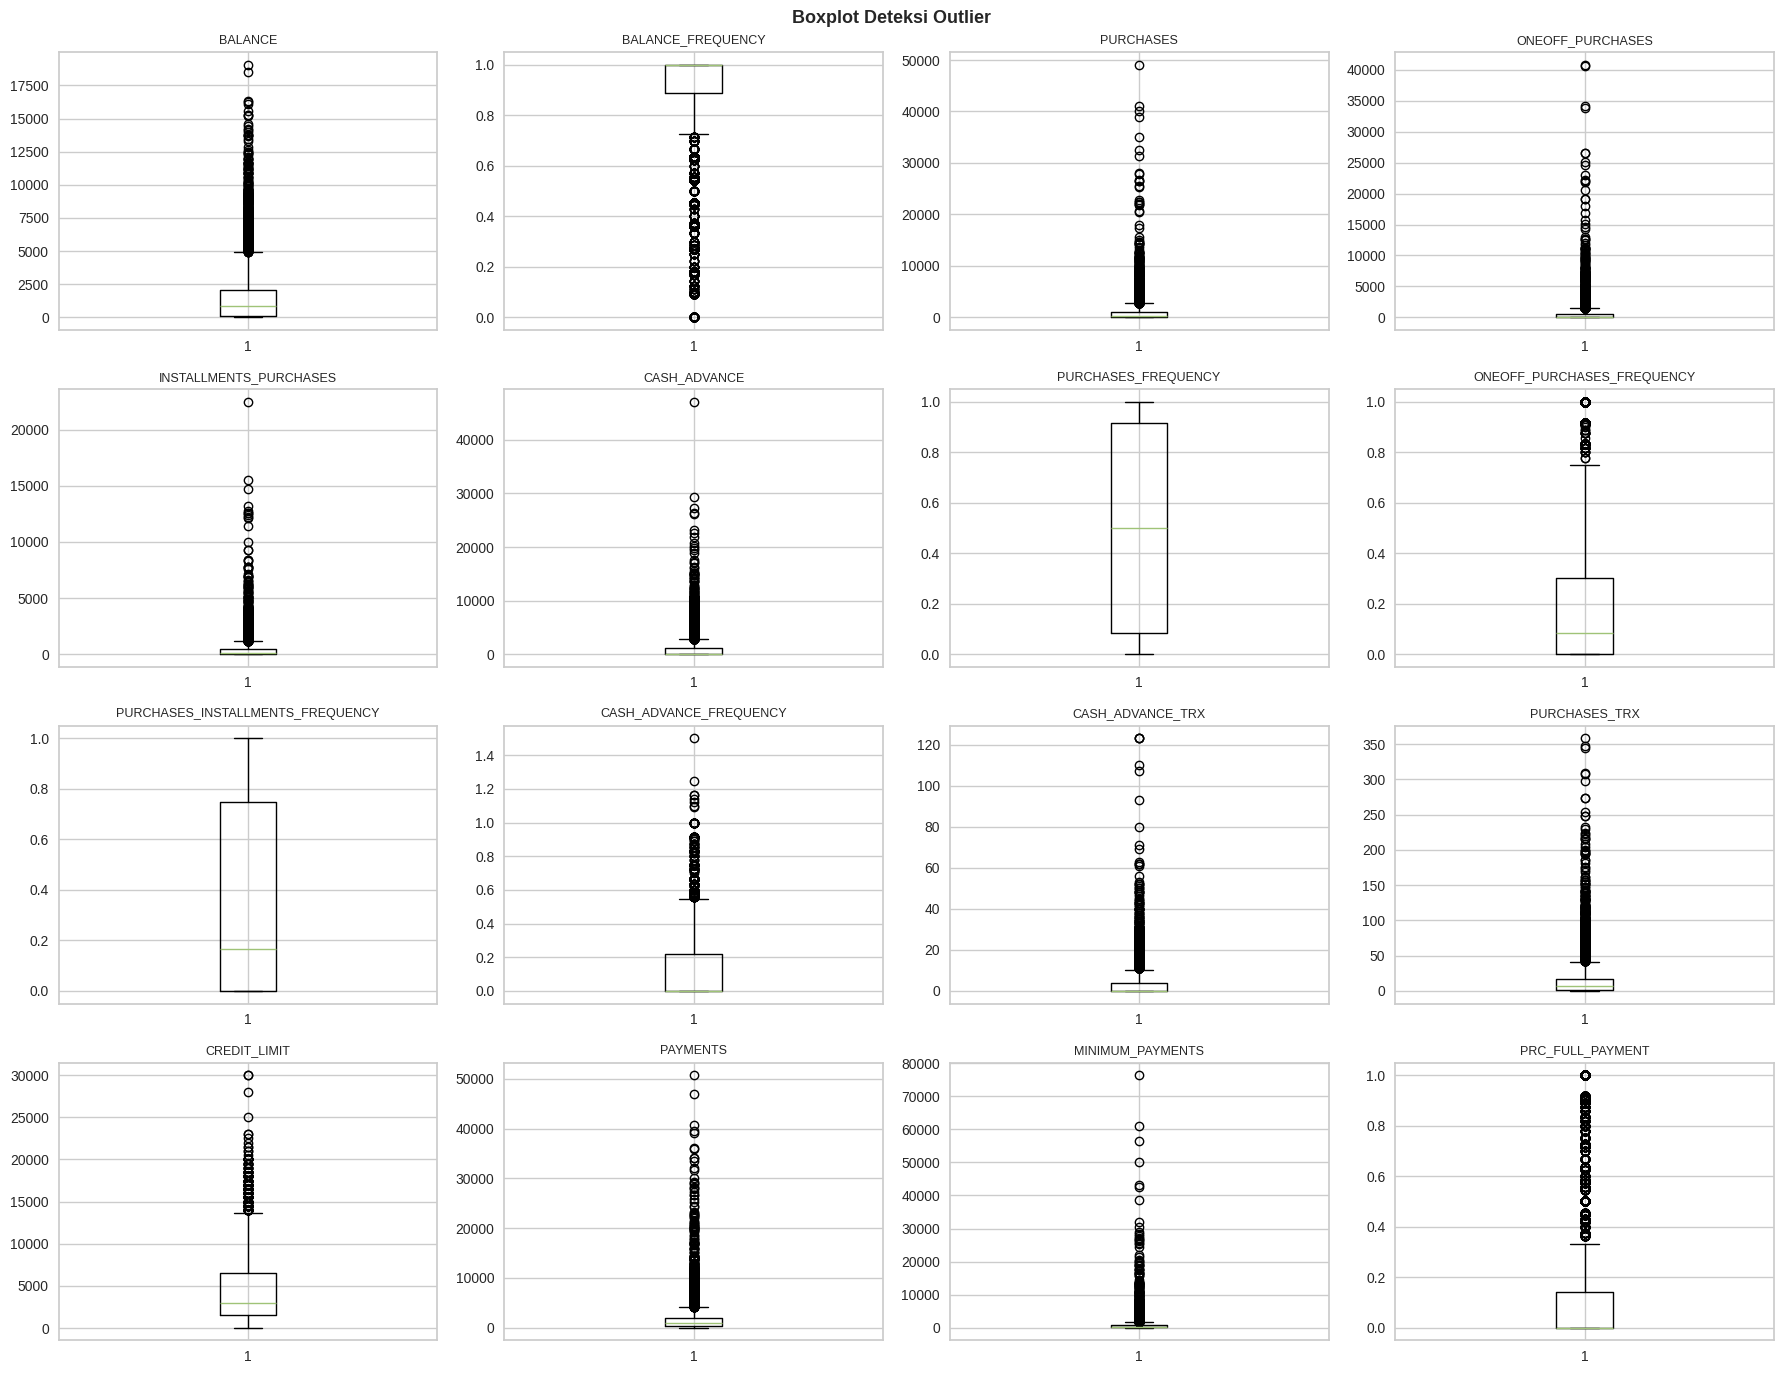

In [9]:
# Boxplot untuk deteksi outlier
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(num_cols[:16]):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col, fontsize=9)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplot Deteksi Outlier', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

In [10]:
# Drop kolom ID (tidak dipakai untuk clustering)
if 'CUST_ID' in df.columns:
    cust_ids = df['CUST_ID'].copy()
    df_feat  = df.drop(columns=['CUST_ID'])
else:
    df_feat = df.copy()

# Hanya ambil kolom numerik
df_feat = df_feat.select_dtypes(include='number')
feature_names = df_feat.columns.tolist()

print(f'Fitur untuk clustering: {len(feature_names)} kolom')
print(feature_names)

Fitur untuk clustering: 17 kolom
['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']


In [11]:
# Imputasi missing values dengan median
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(df_feat)
print(f'✅ Imputasi selesai. Sisa NaN: {np.isnan(X_imputed).sum()}')

✅ Imputasi selesai. Sisa NaN: 0


In [12]:
# Handle outlier dengan IQR clipping
df_clean = pd.DataFrame(X_imputed, columns=feature_names)
for col in feature_names:
    Q1  = df_clean[col].quantile(0.25)
    Q3  = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    df_clean[col] = df_clean[col].clip(Q1 - 3*IQR, Q3 + 3*IQR)

print('✅ Outlier clipping selesai (IQR x3)')

✅ Outlier clipping selesai (IQR x3)


In [13]:
# Standard Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)

print(f'✅ Scaling selesai. Shape: {X_scaled.shape}')

✅ Scaling selesai. Shape: (8950, 17)


In [14]:
# PCA untuk visualisasi 2D
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

print(f'✅ PCA selesai')
print(f'   Explained variance ratio: {pca.explained_variance_ratio_}')
print(f'   Total explained         : {pca.explained_variance_ratio_.sum():.4f}')

✅ PCA selesai
   Explained variance ratio: [0.3231521  0.24985301]
   Total explained         : 0.5730


## 5. Menentukan Jumlah Cluster Optimal

Gunakan **Elbow Method** dan **Silhouette Score** untuk menemukan jumlah cluster terbaik.

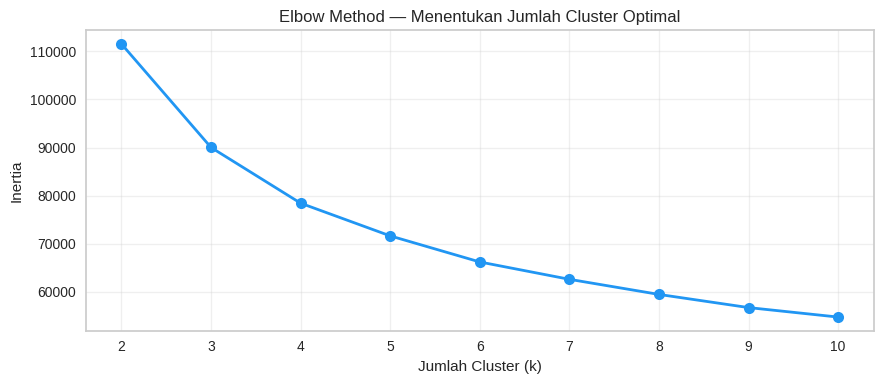

Perhatikan titik "siku" pada grafik — itulah k optimal!


In [15]:
# Elbow Method
inertias = []
k_range  = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(9, 4))
plt.plot(k_range, inertias, marker='o', color='#2196F3', linewidth=2, markersize=8)
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Menentukan Jumlah Cluster Optimal')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Perhatikan titik "siku" pada grafik — itulah k optimal!')

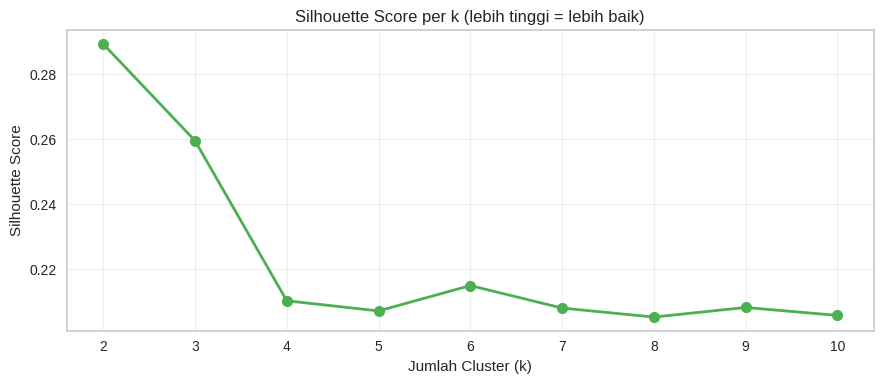


✅ K optimal berdasarkan Silhouette Score: k = 2
   Silhouette Score terbaik: 0.2893


In [16]:
# Silhouette Score untuk tiap k
sil_scores = []
for k in k_range:
    km     = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(9, 4))
plt.plot(k_range, sil_scores, marker='o', color='#4CAF50', linewidth=2, markersize=8)
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score per k (lebih tinggi = lebih baik)')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_k = k_range[np.argmax(sil_scores)]
print(f'\n✅ K optimal berdasarkan Silhouette Score: k = {best_k}')
print(f'   Silhouette Score terbaik: {max(sil_scores):.4f}')

In [17]:
# Gunakan k optimal dari analisis di atas
K_OPTIMAL = best_k
print(f'K yang digunakan untuk clustering: {K_OPTIMAL}')

K yang digunakan untuk clustering: 2


## 6. Model Training

Training 3 model clustering: **K-Means**, **Hierarchical (Agglomerative)**, dan **DBSCAN**.

In [18]:
# Model 1: K-Means
print(f'Training K-Means (k={K_OPTIMAL})...')
kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=SEED, n_init=10)
labels_kmeans = kmeans.fit_predict(X_scaled)

print(f'✅ K-Means selesai')
print(f'   Distribusi cluster: {dict(pd.Series(labels_kmeans).value_counts().sort_index())}')

Training K-Means (k=2)...
✅ K-Means selesai
   Distribusi cluster: {0: np.int64(2105), 1: np.int64(6845)}


In [19]:
# Model 2: Hierarchical Clustering
print(f'Training Hierarchical Clustering (k={K_OPTIMAL})...')
hierarchical = AgglomerativeClustering(n_clusters=K_OPTIMAL, linkage='ward')
labels_hier  = hierarchical.fit_predict(X_scaled)

print(f'✅ Hierarchical selesai')
print(f'   Distribusi cluster: {dict(pd.Series(labels_hier).value_counts().sort_index())}')

Training Hierarchical Clustering (k=2)...
✅ Hierarchical selesai
   Distribusi cluster: {0: np.int64(7157), 1: np.int64(1793)}


Membuat dendrogram (sample 200 data)...


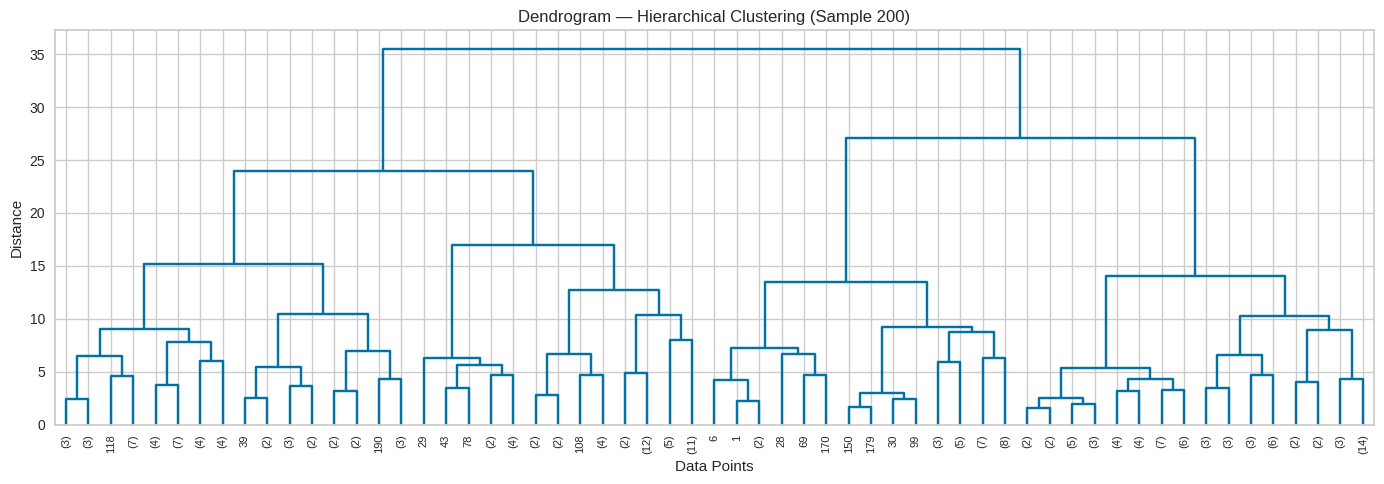

In [20]:
# Dendrogram (sample 200 data)
print('Membuat dendrogram (sample 200 data)...')
sample_idx = np.random.choice(len(X_scaled), 200, replace=False)
X_sample   = X_scaled[sample_idx]

linked = linkage(X_sample, method='ward')

plt.figure(figsize=(14, 5))
dendrogram(linked, truncate_mode='level', p=5,
           leaf_rotation=90, leaf_font_size=8, color_threshold=0)
plt.title('Dendrogram — Hierarchical Clustering (Sample 200)')
plt.xlabel('Data Points')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

In [21]:
# Model 3: DBSCAN
print('Training DBSCAN...')
dbscan = DBSCAN(eps=1.5, min_samples=5, n_jobs=-1)
labels_dbscan = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise       = list(labels_dbscan).count(-1)

print(f'✅ DBSCAN selesai')
print(f'   Jumlah cluster ditemukan : {n_clusters_db}')
print(f'   Jumlah noise points      : {n_noise} ({n_noise/len(labels_dbscan)*100:.1f}%)')
print(f'   Distribusi: {dict(pd.Series(labels_dbscan).value_counts().sort_index())}')

Training DBSCAN...
✅ DBSCAN selesai
   Jumlah cluster ditemukan : 8
   Jumlah noise points      : 1512 (16.9%)
   Distribusi: {-1: np.int64(1512), 0: np.int64(7391), 1: np.int64(22), 2: np.int64(3), 3: np.int64(5), 4: np.int64(5), 5: np.int64(5), 6: np.int64(4), 7: np.int64(3)}


## 7. Evaluasi Cluster

Metrik evaluasi:
- **Silhouette Score**: semakin tinggi semakin baik (range -1 sampai 1)
- **Davies-Bouldin Score**: semakin rendah semakin baik
- **Calinski-Harabasz Score**: semakin tinggi semakin baik

In [22]:
def evaluate_clustering(name, labels, X):
    # Filter noise untuk DBSCAN
    mask = labels != -1
    if mask.sum() < 2 or len(set(labels[mask])) < 2:
        print(f'{name}: tidak cukup cluster untuk evaluasi')
        return None

    sil = silhouette_score(X[mask], labels[mask])
    db  = davies_bouldin_score(X[mask], labels[mask])
    ch  = calinski_harabasz_score(X[mask], labels[mask])

    print(f'\n===== {name} =====')
    print(f'  Silhouette Score        : {sil:.4f}  (↑ lebih baik)')
    print(f'  Davies-Bouldin Score    : {db:.4f}  (↓ lebih baik)')
    print(f'  Calinski-Harabasz Score : {ch:.4f}  (↑ lebih baik)')
    return {'Silhouette': sil, 'Davies-Bouldin': db, 'Calinski-Harabasz': ch}

eval_results = {}
r = evaluate_clustering('K-Means', labels_kmeans, X_scaled)
if r: eval_results['K-Means'] = r

r = evaluate_clustering('Hierarchical', labels_hier, X_scaled)
if r: eval_results['Hierarchical'] = r

r = evaluate_clustering('DBSCAN', labels_dbscan, X_scaled)
if r: eval_results['DBSCAN'] = r


===== K-Means =====
  Silhouette Score        : 0.2893  (↑ lebih baik)
  Davies-Bouldin Score    : 1.6013  (↓ lebih baik)
  Calinski-Harabasz Score : 2537.6547  (↑ lebih baik)

===== Hierarchical =====
  Silhouette Score        : 0.2445  (↑ lebih baik)
  Davies-Bouldin Score    : 1.7188  (↓ lebih baik)
  Calinski-Harabasz Score : 1850.5362  (↑ lebih baik)

===== DBSCAN =====
  Silhouette Score        : 0.0413  (↑ lebih baik)
  Davies-Bouldin Score    : 0.8551  (↓ lebih baik)
  Calinski-Harabasz Score : 28.1114  (↑ lebih baik)


In [23]:
# Tabel perbandingan
if eval_results:
    eval_df = pd.DataFrame(eval_results).T.round(4)
    print('=== Perbandingan Evaluasi Semua Model ===')
    display(eval_df.style
        .highlight_max(subset=['Silhouette', 'Calinski-Harabasz'], axis=0, color='#a8f0a8')
        .highlight_min(subset=['Davies-Bouldin'], axis=0, color='#a8f0a8')
    )

=== Perbandingan Evaluasi Semua Model ===


,Silhouette,Davies-Bouldin,Calinski-Harabasz
K-Means,0.289300,1.601300,2537.654700
Hierarchical,0.244500,1.718800,1850.536200
DBSCAN,0.041300,0.855100,28.111400


## 8. Visualisasi & Interpretasi Cluster

Fokus pada **K-Means** sebagai model utama karena paling stabil dan mudah diinterpretasi.

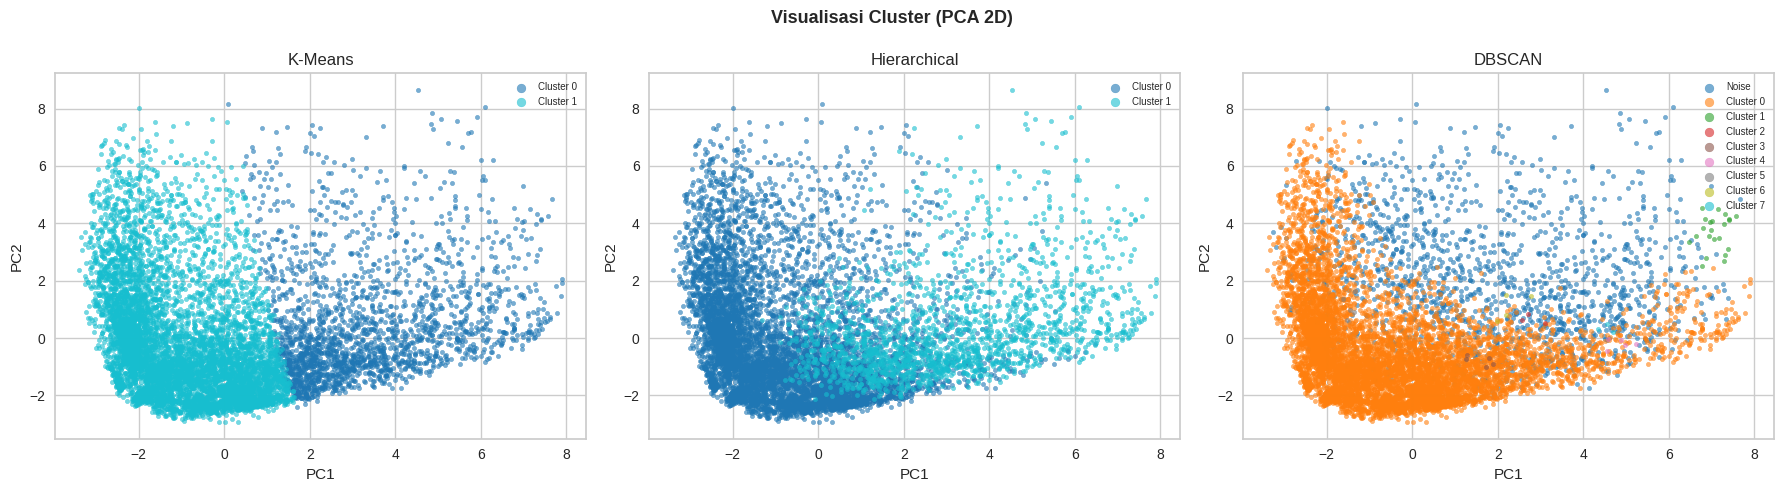

In [24]:
# Visualisasi PCA 2D untuk semua model
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

all_labels = [
    ('K-Means', labels_kmeans),
    ('Hierarchical', labels_hier),
    ('DBSCAN', labels_dbscan)
]

for ax, (name, labels) in zip(axes, all_labels):
    unique_labels = sorted(set(labels))
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
    for label, color in zip(unique_labels, colors):
        mask = labels == label
        lname = f'Noise' if label == -1 else f'Cluster {label}'
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=[color], label=lname, s=10, alpha=0.6)
    ax.set_title(f'{name}')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(fontsize=7, markerscale=2)

plt.suptitle('Visualisasi Cluster (PCA 2D)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

=== Profil Rata-rata Tiap Cluster (K-Means) ===


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,1942.26,0.97,2499.26,1249.33,959.31,542.46,0.91,0.53,0.71,0.08,1.79,36.25,6717.12,2734.01,764.36,0.19,12.0
1,1387.34,0.89,328.20,174.99,152.48,888.59,0.36,0.10,0.26,0.15,3.08,5.91,3805.67,1112.74,580.95,0.09,12.0


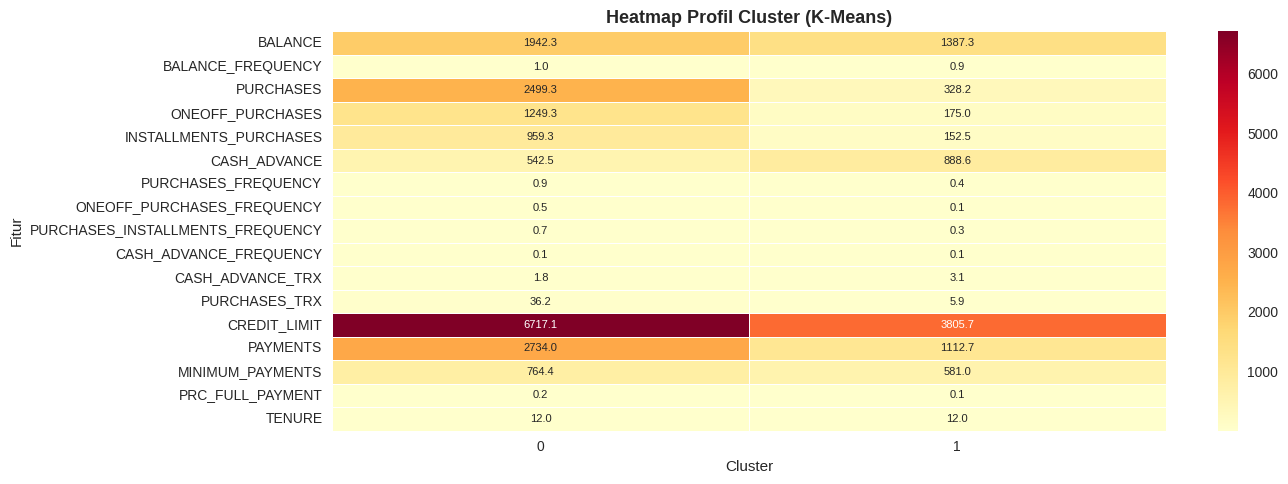

In [25]:
# Profil tiap cluster K-Means
df_result = df_clean.copy()
df_result['Cluster'] = labels_kmeans

cluster_profile = df_result.groupby('Cluster').mean().round(2)
print('=== Profil Rata-rata Tiap Cluster (K-Means) ===')
display(cluster_profile)

# Heatmap profil cluster
plt.figure(figsize=(14, 5))
sns.heatmap(
    cluster_profile.T,
    annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.5, annot_kws={'size': 8}
)
plt.title('Heatmap Profil Cluster (K-Means)', fontsize=13, fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()

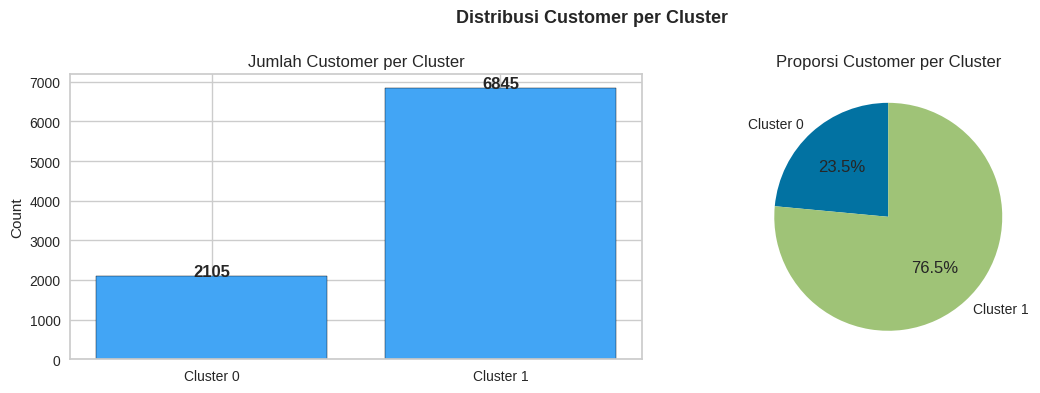

In [26]:
# Ukuran tiap cluster
cluster_sizes = pd.Series(labels_kmeans).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar([f'Cluster {i}' for i in cluster_sizes.index],
            cluster_sizes.values, color='#42A5F5', edgecolor='black')
axes[0].set_title('Jumlah Customer per Cluster')
axes[0].set_ylabel('Count')
for i, v in enumerate(cluster_sizes.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

axes[1].pie(cluster_sizes.values,
            labels=[f'Cluster {i}' for i in cluster_sizes.index],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proporsi Customer per Cluster')

plt.suptitle('Distribusi Customer per Cluster', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

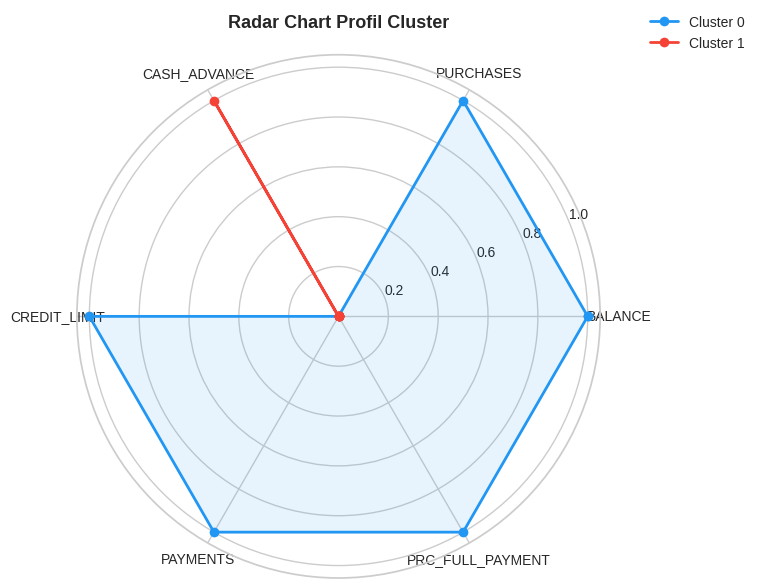

In [27]:
# Radar chart profil cluster (fitur utama)
key_features = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE',
                'CREDIT_LIMIT', 'PAYMENTS', 'PRC_FULL_PAYMENT']
key_features = [f for f in key_features if f in df_result.columns]

if len(key_features) >= 3:
    # Normalisasi untuk radar
    profile_norm = cluster_profile[key_features].copy()
    profile_norm = (profile_norm - profile_norm.min()) / (profile_norm.max() - profile_norm.min() + 1e-9)

    angles = np.linspace(0, 2*np.pi, len(key_features), endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    colors  = ['#2196F3', '#F44336', '#4CAF50', '#FF9800', '#9C27B0']

    for i, (cluster_id, row) in enumerate(profile_norm.iterrows()):
        values = row.tolist() + row.tolist()[:1]
        ax.plot(angles, values, 'o-', linewidth=2,
                color=colors[i % len(colors)], label=f'Cluster {cluster_id}')
        ax.fill(angles, values, alpha=0.1, color=colors[i % len(colors)])

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(key_features, size=10)
    ax.set_title('Radar Chart Profil Cluster', fontsize=13, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()
    plt.show()

## Interpretasi Cluster

| Cluster | Nama Segmen | Karakteristik |
|---|---|---|
| 0 | **Premium Active Customer** | Balance tinggi (1942), purchases sangat tinggi (2499), credit limit besar (6717), payments tinggi (2734), sering belanja (frequency 0.91) |
| 1 | **Cash-Dependent Customer** | Cash advance tinggi (889), purchases rendah (328), credit limit lebih kecil (3806), jarang belanja (frequency 0.36), lebih sering tarik tunai |

**Analisis Detail:**

**Cluster 0 — Premium Active Customer (Pelanggan Aktif Premium)**
- PURCHASES tertinggi (2499) → banyak transaksi belanja
- CREDIT_LIMIT besar (6717) → dipercaya bank dengan limit tinggi
- PAYMENTS tinggi (2734) → rajin membayar tagihan
- ONEOFF_PURCHASES tinggi (1249) → sering belanja sekaligus dalam jumlah besar
- Segmen ini adalah customer paling menguntungkan bagi bank

**Cluster 1 — Cash-Dependent Customer (Pelanggan Bergantung Tunai)**
- CASH_ADVANCE sangat tinggi (889) → sering tarik tunai dari kartu kredit
- PURCHASES rendah (328) → jarang belanja menggunakan kartu
- CREDIT_LIMIT lebih rendah (3806) → limit kartu lebih kecil
- CASH_ADVANCE_TRX tinggi (3.1) → frekuensi tarik tunai lebih sering
- Segmen ini berisiko lebih tinggi karena cash advance biasanya berbunga tinggi

**Model Terbaik**: K-Means  
**Jumlah Cluster Optimal**: 2, berdasarkan Elbow Method dan Silhouette Score tertinggi

In [28]:
print('=' * 55)
print('         RINGKASAN HASIL CLUSTERING')
print('=' * 55)
print(f'Jumlah data     : {len(df_result)}')
print(f'Jumlah fitur    : {len(feature_names)}')
print(f'K optimal       : {K_OPTIMAL}')
print()
if eval_results:
    print(f'{"Model":<15} {"Silhouette":>12} {"Davies-B":>12} {"Calinski":>12}')
    print('-' * 55)
    for name, m in eval_results.items():
        print(f'{name:<15} {m["Silhouette"]:>12.4f} {m["Davies-Bouldin"]:>12.4f} {m["Calinski-Harabasz"]:>12.4f}')
print('=' * 55)
print('\n✅ Pipeline clustering selesai!')

         RINGKASAN HASIL CLUSTERING
Jumlah data     : 8950
Jumlah fitur    : 17
K optimal       : 2

Model             Silhouette     Davies-B     Calinski
-------------------------------------------------------
K-Means               0.2893       1.6013    2537.6547
Hierarchical          0.2445       1.7188    1850.5362
DBSCAN                0.0413       0.8551      28.1114

✅ Pipeline clustering selesai!
